Ini adalah notebook untuk menyimpan data yang dibutuhkan. Secara general data akan dibagi menjadi 2 jenis. Yang pertama adalah data rule dan Pedoman kampus. Yang kedua adalah data mahasiswa

## Data Pedoman dan Rule

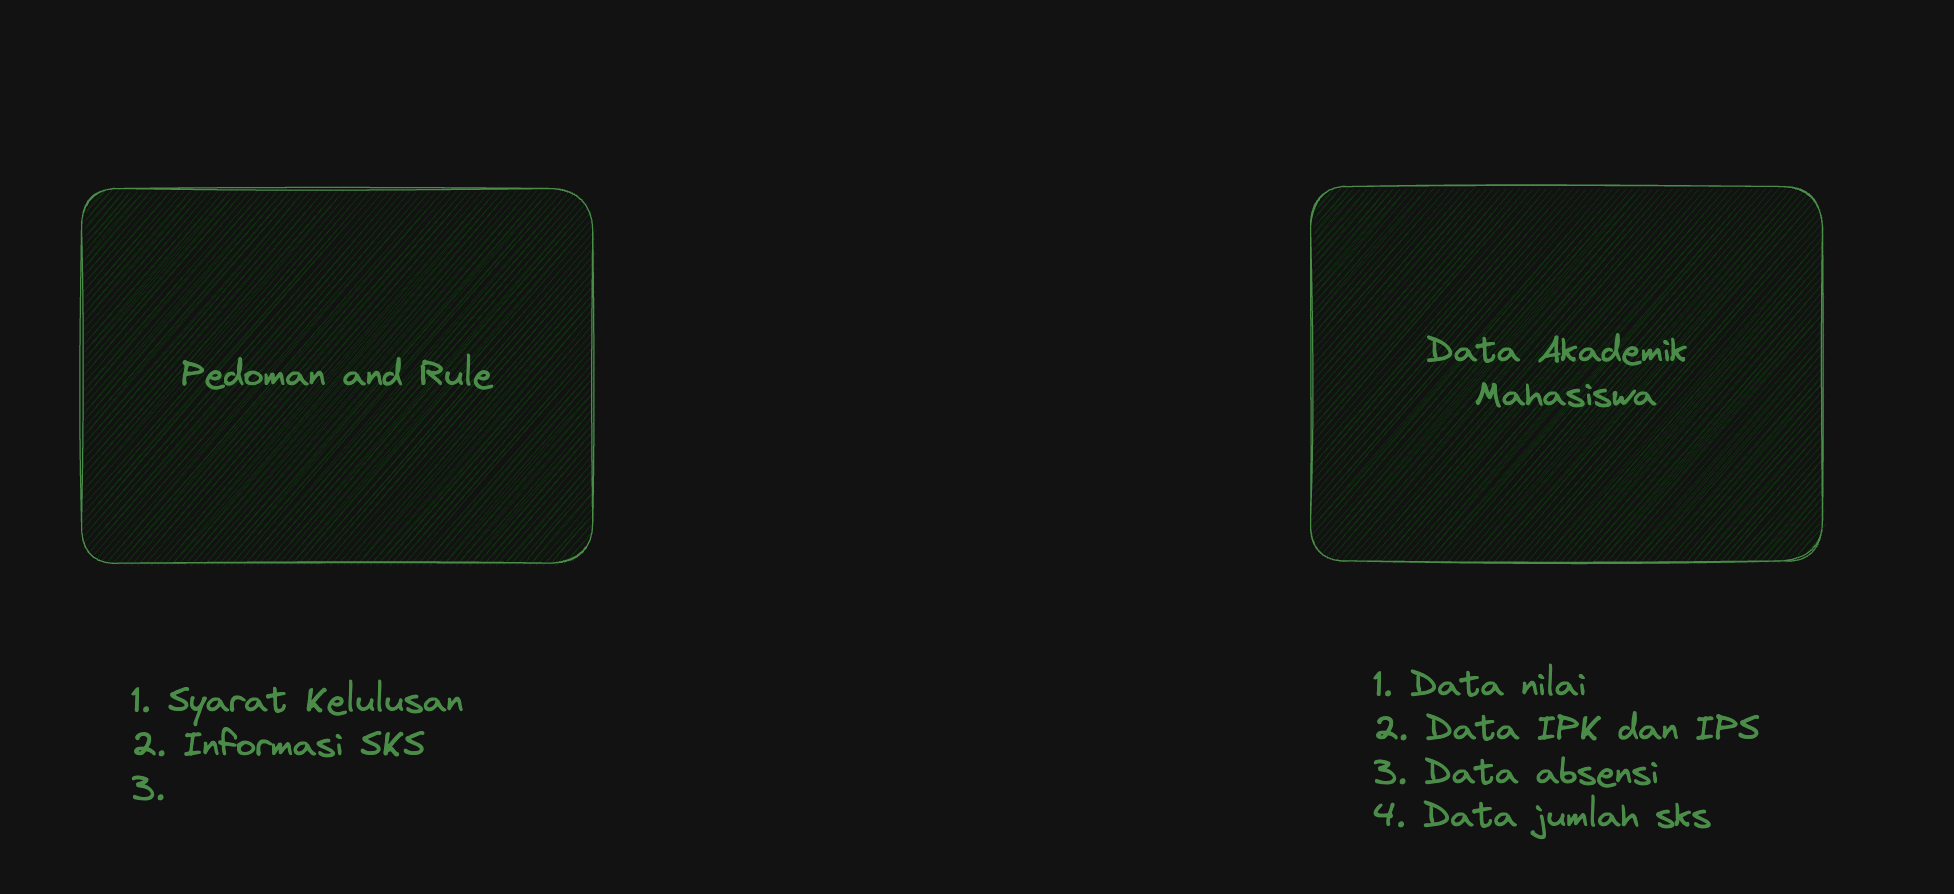

In [1]:
data_pedoman_dan_rule = {
    "data":[
        "https://akademik.nurulfikri.ac.id/1-satuan-kredit-semester-sks/",
        "https://akademik.nurulfikri.ac.id/1-syarat-kelulusan/",
        "https://akademik.nurulfikri.ac.id/2-aturan/",
        "https://akademik.nurulfikri.ac.id/3-kode-etik-mahasiswa/",
        "https://akademik.nurulfikri.ac.id/4-suasana-akademik/",
        "https://akademik.nurulfikri.ac.id/4-profil-dosen/",
        "https://akademik.nurulfikri.ac.id/1-sejarah/"

    ],
    "sumber_data":[
        "satuan kredit semester",
        "syarat kelulusan",
        "aturan dan kode etik",
        "kode etik mahasiswa",
        "suasana akademik",
        "profile dosen",
        "sejarah sttnf"
    ]

}

In [2]:
# testing pengambilan data dosen
from langchain_community.document_loaders import WebBaseLoader

# loader = WebBaseLoader("https://akademik.nurulfikri.ac.id/4-profil-dosen/")

/Users/a/Programming/Langchain-Project/my-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
# featch keseluruhan data pedoman dan rule

loader = WebBaseLoader(data_pedoman_dan_rule['data'])

In [4]:
pages = []

for doc in loader.lazy_load():
    pages.append(doc)

In [5]:
print(pages[0])

page_content='





1. Satuan Kredit Semester (SKS) – Pedoman Akademik STT-NF

























































ADMINISTRASI


1. Daftar Ulang
2. Administrasi Keuangan
3. BAAK
4. UPT Perpustakaan





KELULUSAN


1. Syarat Kelulusan
2. Yudisium
3. Syarat Pengambilan SKL, Transkrip, dan Ijazah
4. Wisuda





MBKM


1. Pedoman MBKM
2. Administrasi
3. Konversi SKS





ORGANISASI KEMAHASISWAAN


1. Tentang Organisasi Kemahasiswaan
2. Aturan
3. Fasilitas Mahasiswa
4. Soft Skill
5. Mars STT Terpadu Nurul Fikri
6. Hymne STT Terpadu Nurul Fikri





PENUNJANG AKADEMIK


1. Penelitian Dan PKM
2. Laboratorium
3. Perpustakaan
4. Pengembangan Diri Mahasiswa
5. Unit Pendukung Kemahasiswaan
6. Alumni





PENYELENGGARAAN AKADEMIK


1. Satuan Kredit Semester (SKS)
2. Pelaksanaan Perkuliahan
3. Kode Etik Mahasiswa
4. Suasana Akademik
5. Kalender Akademik





PROGRAM STUDI


1. Sistem Informasi
2. Teknik Informatika
3. Bisnis Digital





SARANA DAN PRASARANA


1. Daftar Sarpra

### chunking dokumen pedoman dan rule

In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [7]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

In [8]:
docs_splits = text_splitter.split_documents(pages)

In [9]:
print(docs_splits[60])

page_content='25
0409059502
7841773674130262
Rian Adha Ardinata, S.Biotek., M.M.


26
0416099601
7248774675230213
Cindy Suci Ananda, S.Biotek., M.M.


27
0412079502
1044773674130313
Dani Wijaya, S.Biotek., M.Sc.


28
0420117706
2452755656130143
R Adhari Cahya Mahendra, S.Kom., M.Kom.


29
–
4450759660131082
Maulana Fakih Latief, S.Si., M.Si.




B. Prodi Sistem Informasi






No
NIDN
NUPTK
NAMA




1
0402018701
6434765666230762
Dr. Amalia Rahmah, S.T., M.T.


2
0404017602
0436754655130122
Bachtiar Firdaus, S.T., M.P.


3
9903019258 (NUP)
–
Dr. Bambang Priantono, M.T.


4
0415108403
5347762663130233
Kurniawan Dwi Prasetyo, S.T., M.T.


5
0431088701
2163765666130223
Nugroho Dwi Saputra, S.Kom., M.Ti.


6
0423076303
0055741642130083
Drs. Rusmanto, M.M.


7
0426096501
4258743644130053
Dr. Sapto Waluyo, S.Sos., M.Sc.


8
0006067204
0938750651130222
Dr. Suhendi, S.T., S.Kom., M.M.S.I.


9
0401017122
3433749650131192
Warsono, S.Kom., M.Ti.


10
0424098604
1256764665230193
Yekti Wirani, S.T.,

### Retrieve data pedoman dan rule

In [10]:
from langchain_community.retrievers import BM25Retriever

In [11]:
retriever = BM25Retriever.from_documents(docs_splits)
retriever.k = 3

In [19]:
retriever.invoke("apa saja syarat kelulusan")

[Document(metadata={'source': 'https://akademik.nurulfikri.ac.id/3-kode-etik-mahasiswa/', 'title': '3. Kode Etik Mahasiswa – Pedoman Akademik STT-NF', 'language': 'en-US'}, page_content='Sekolah Tinggi adalah Sekolah Tinggi Teknologi Terpadu Nurul Fikri.\nYayasan adalah Yayasan Profesi Terpadu Nurul Fikri sebagai penyelenggara Sekolah Tinggi Terpadu Nurul Fikri.\nKetua adalah Ketua Sekolah Tinggi Teknologi Terpadu Nurul Fikri.\nSenat Akademik Sekolah Tinggi merupakan organ yang secara independen melaksanakan pemeriksaan atas pelanggaran Kode Etik.\nEtika merupakan filsafat praktis, artinya filsafat yang ingin memberikan penyuluhan kepada tingkah laku manusia dengan memperhatikan apa yang harus dilakukan.\nKode Etik adalah serangkaian norma-norma etik yang memuat hak dan kewajiban yang bersumber pada nilai-nilai etik yang dijadikan sebagai pedoman berfikir, bersikap, dan bertindak dalam aktivitas-aktivitas yang menuntut tanggung jawab profesi.\nIntegritas akademik adalah prinsip etika y

## Data Akademik Mahasiswa

In [25]:
data_akademik = "/Users/a/Programming/Langchain-Project/external-data/sintetik-data-akademik-mahasiswa.xlsx"

In [26]:
from typing import Iterator
from langchain_core.document_loaders import BaseLoader
from langchain_core.documents import Document as LCDocument
from docling.document_converter import DocumentConverter


In [27]:
class DoclingPDFLoader(BaseLoader):
    def __init__(self, file_path: str | list[str]) -> None:
        self._file_paths = file_path if isinstance(file_path, list) else [file_path]
        self._converter = DocumentConverter()


    def lazy_load(self) -> Iterator[LCDocument]:
        for source in self._file_paths:
            dl_doc = self._converter.convert(source).document
            text = dl_doc.export_to_markdown()
            yield LCDocument(page_content=text)

In [28]:
loader = DoclingPDFLoader(data_akademik)

In [29]:
docs = loader.load()

2026-01-28 10:13:20,193 - INFO - detected formats: [<InputFormat.XLSX: 'xlsx'>]
2026-01-28 10:13:20,210 - INFO - Going to convert document batch...
2026-01-28 10:13:20,211 - INFO - Initializing pipeline for SimplePipeline with options hash 995a146ad601044538e6a923bea22f4e
2026-01-28 10:13:20,354 - WARNING - The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
2026-01-28 10:13:20,354 - INFO - Loading plugin 'docling_defaults'
2026-01-28 10:13:20,356 - INFO - Registered picture descriptions: ['vlm', 'api']
2026-01-28 10:13:20,357 - INFO - Processing document sintetik-data-akademik-mahasiswa.xlsx
2026-01-28 10:13:20,357 - INFO - Processing sheet 0: Data Mahasiswa Sintetik untuk R
2026-01-28 10:13:20,365 - INFO - Finished converting document sintetik-data-akademik-mahasiswa.xlsx in 0.18 sec.


In [32]:
print(docs[0])

page_content='|   No |         NIM | Nama Mahasiswa     | Jurusan          |   Semester |   Total SKS |   IPS |   IPK |   Kehadiran (%) | Status    |
|------|-------------|--------------------|------------------|------------|-------------|-------|-------|-----------------|-----------|
|    1 | 2.021e+07   | Aditya Pratama     | T. Informatika   |          5 |          18 |  3.5  |  3.65 |              95 | Aktif     |
|    2 | 2.021e+07   | Budi Santoso       | T. Informatika   |          5 |          20 |  2.8  |  3.1  |              82 | Aktif     |
|    3 | 2.021e+07   | Citra Lestari      | T. Informatika   |          5 |          22 |  3.85 |  3.9  |              98 | Aktif     |
|    4 | 2.021e+07   | Dewa Anggara       | T. Informatika   |          5 |          18 |  1.9  |  2.45 |              65 | Percobaan |
|    5 | 2.021e+07   | Eka Kurniawan      | T. Informatika   |          5 |          20 |  3.2  |  3.3  |              88 | Aktif     |
|    6 | 2.021e+07   | Fajar Sidiq

In [33]:
split_data_akademik = text_splitter.split_documents(docs)

In [36]:
print(split_data_akademik[0])

page_content='|   No |         NIM | Nama Mahasiswa     | Jurusan          |   Semester |   Total SKS |   IPS |   IPK |   Kehadiran (%) | Status    |
|------|-------------|--------------------|------------------|------------|-------------|-------|-------|-----------------|-----------|
|    1 | 2.021e+07   | Aditya Pratama     | T. Informatika   |          5 |          18 |  3.5  |  3.65 |              95 | Aktif     |
|    2 | 2.021e+07   | Budi Santoso       | T. Informatika   |          5 |          20 |  2.8  |  3.1  |              82 | Aktif     |
|    3 | 2.021e+07   | Citra Lestari      | T. Informatika   |          5 |          22 |  3.85 |  3.9  |              98 | Aktif     |
|    4 | 2.021e+07   | Dewa Anggara       | T. Informatika   |          5 |          18 |  1.9  |  2.45 |              65 | Percobaan |
|    5 | 2.021e+07   | Eka Kurniawan      | T. Informatika   |          5 |          20 |  3.2  |  3.3  |              88 | Aktif     |'


In [47]:
retriever_data_akademik = BM25Retriever.from_documents(split_data_akademik)
retriever.k = 3

In [49]:
retriever_data_akademik.invoke("Eka Kurniawan")

[Document(metadata={}, page_content='|   No |         NIM | Nama Mahasiswa     | Jurusan          |   Semester |   Total SKS |   IPS |   IPK |   Kehadiran (%) | Status    |\n|------|-------------|--------------------|------------------|------------|-------------|-------|-------|-----------------|-----------|\n|    1 | 2.021e+07   | Aditya Pratama     | T. Informatika   |          5 |          18 |  3.5  |  3.65 |              95 | Aktif     |\n|    2 | 2.021e+07   | Budi Santoso       | T. Informatika   |          5 |          20 |  2.8  |  3.1  |              82 | Aktif     |\n|    3 | 2.021e+07   | Citra Lestari      | T. Informatika   |          5 |          22 |  3.85 |  3.9  |              98 | Aktif     |\n|    4 | 2.021e+07   | Dewa Anggara       | T. Informatika   |          5 |          18 |  1.9  |  2.45 |              65 | Percobaan |\n|    5 | 2.021e+07   | Eka Kurniawan      | T. Informatika   |          5 |          20 |  3.2  |  3.3  |              88 | Aktif     |'),
 D

In [37]:
import getpass
import os

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google AI API key: ")

In [38]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.runnables import RunnableParallel, RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

model = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
    
)

In [39]:
setup_and_retrieval = RunnableParallel(
    {
        "context":retriever,
        "question":RunnablePassthrough()
    }
)

In [40]:
prompt = ChatPromptTemplate.from_template(
    """Kamu adalah asisten cerdas. Jawablah pertanyaan pengguna berdasarkan konteks berikut ini saja.
    
    KONTEKS:
    {context}
    
    INSTRUKSI TAMBAHAN:
    1. Jawablah pertanyaan berdasarkan KONTEKS di atas.
    2. Kamu WAJIB menjawab dalam Bahasa Indonesia, terlepas dari bahasa apa pertanyaan itu diberikan.
    3. Jika jawaban tidak ada di dalam konteks, katakan "Maaf, informasi tidak ditemukan dalam dokumen."
    
    PERTANYAAN: {question}
    JAWABAN:"""
)

In [41]:
chain_gemini = setup_and_retrieval | prompt | model | StrOutputParser()

In [ ]:
print(chain_gemini.invoke(""))

2026-01-28 10:20:36,146 - INFO - AFC is enabled with max remote calls: 10.
2026-01-28 10:20:40,730 - INFO - HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent "HTTP/1.1 200 OK"


Maaf, informasi tidak ditemukan dalam dokumen.
